# Régimen Ultra Transmon
Evaluamos algunas aproximaciones considerando que estamos en el régimen ultra transmon ($E_J / E_c \sim 100$ )

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.special import genlaguerre, gammaln
import itertools
import scienceplots
plt.style.use(['science', 'notebook'])

In [2]:
# expresion analitica para la matriz (en base de fock) del operador e^{i u (\hat a + \hat a^\dag)}
def compute_position_exponential(N, u): 
  matrix = np.zeros(shape=(N, N), dtype=complex)
  for m in range(N):
    for n in range(N):
      if m >= n:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(n+1) - gammaln(m+1)))
          * (1.0j*u)**(m-n)
          * genlaguerre(n, m-n)(u**2)
        )
      else:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(m+1) - gammaln(n+1)))
          * (1.0j*u)**(n-m)
          * genlaguerre(m, n-m)(u**2)
        )

  return qt.Qobj(matrix)

# hamiltoniano exacto con dimensión truncada en N estados de Fock
def exact_transmon_hamiltonian(N, E_c, E_j):
    charge_number = 0.5j * (E_j/(2*E_c))**0.25 * (qt.destroy(N).dag() - qt.destroy(N))
    phase_prefactor = (2 * E_c / E_j)**0.25
    cos_delta = 0.5 * (compute_position_exponential(N, phase_prefactor) + compute_position_exponential(N, -phase_prefactor))
    return 4 * E_c * charge_number**2 - E_j * cos_delta

In [3]:
def exact_transmon_chain(N, n, E_c, E_J, E_g):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    H_j = exact_transmon_hamiltonian(N, E_c, E_J)
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)
    hbar_g = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op

        full_hamiltonian -= hbar_g * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian

def quadratic_transmon_chain(N, n, E_c, E_J, E_g):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    H_j = omega_q * qt.num(N) - (E_c / 2) * (qt.destroy(N)**2 + qt.destroy(N).dag()**2) 
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)
    hbar_g = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op

        full_hamiltonian -= hbar_g * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian

def non_self_pairing_transmon_chain(N, n, E_c, E_J, E_g):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    H_j = omega_q * qt.num(N) - (E_c / 2) * (qt.destroy(N)**2 + qt.destroy(N).dag()**2) 
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)
    hbar_g = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op

        full_hamiltonian -= hbar_g * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian

In [4]:
N = 8
n = 4
E_c = 1.0
E_j = 100.0
E_g_values = E_c * np.linspace(1.0, 3.0, 50)
hamiltonians = [exact_transmon_chain, quadratic_transmon_chain, non_self_pairing_transmon_chain]
energy_matrix = []

for hamiltonian_function in hamiltonians:
    energies = []
    for E_g in E_g_values:
        hamilitonian = hamiltonian_function(N, n, E_c, E_j, E_g)
        energies.append(np.array(hamilitonian.eigenenergies()))

    energy_matrix.append(np.array(energies))

energy_matrix = np.array(energy_matrix)

/tmp/ipykernel_25374/4143595639.py:37: RuntimeWarning: divide by zero encountered in divide
  return 1 / (4 * x)


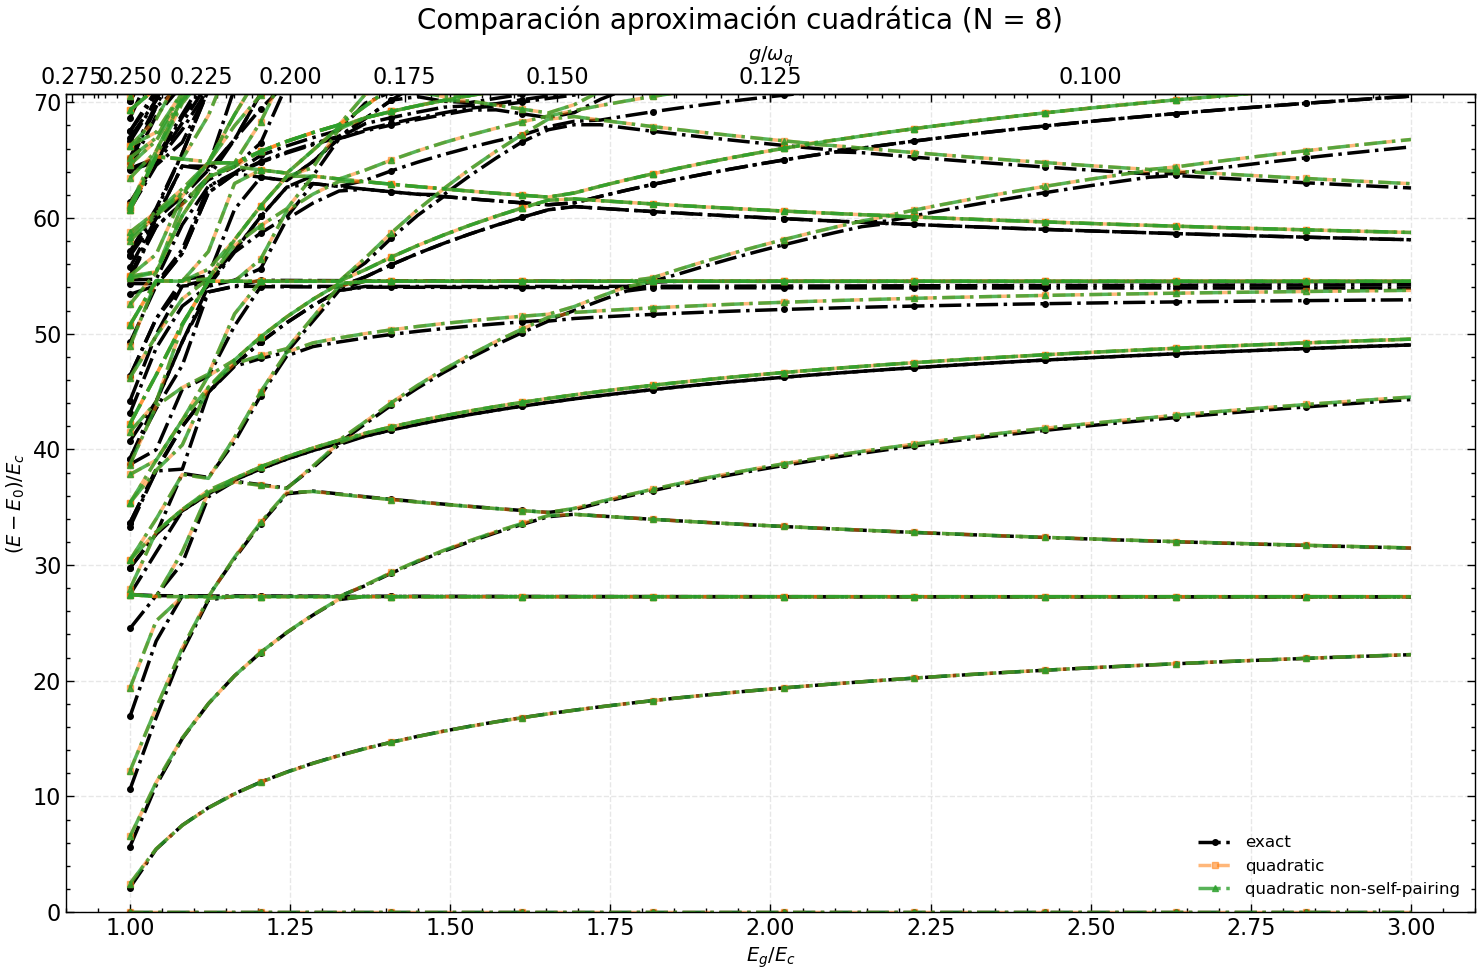

In [10]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Comparación aproximación cuadrática (N = 8)', fontsize=20)

# More distinct styles with different colors, line styles, and markers
styles = [
    {'color': "#000000", 'linestyle': '-.', 'linewidth': 2.5, 'marker': 'o', 'markersize': 4, 'markevery': 5},
    {'color': "#ff7e0e8d", 'linestyle': '--', 'linewidth': 2.5, 'marker': 's', 'markersize': 4, 'markevery': 5},
    {'color': "#2ca02cca", 'linestyle': '-.', 'linewidth': 2.5, 'marker': '^', 'markersize': 4, 'markevery': 5}
]
labels = ['exact', 'quadratic', 'quadratic non-self-pairing']

ax.set_xlabel('$E_g/E_c$', fontsize=14)
ax.set_ylabel('$(E- E_0)/E_c$', fontsize=14)

for energy_array, style, labl in zip(energy_matrix, styles, labels):
    ground = energy_array.T[0]
    for level_idx, level in enumerate(energy_array.T):
        if level_idx == 0:
            ax.plot(E_g_values, np.zeros_like(level), 
                   label=labl, **style)
        else:
            ax.plot(E_g_values, level - ground, **style)

y_min = 0.0
y_max = 50.0 * np.sqrt(2)
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3, linestyle='--')

# Secondary x-axis: np.sqrt((E_j * E_c**3) / 2) / E_g
# Bottom axis is E_g/E_c, so E_g = x * E_c
def bottom_to_top(x):
    # x is E_g/E_c, so E_c/(4*E_g) = 1/(4*x)
    return 1 / (4 * x)

def top_to_bottom(x):
    # Inverse: E_g/E_c = 1/(4*x)
    return 1 / (4 * x)

ax2 = ax.secondary_xaxis('top', functions=(bottom_to_top, top_to_bottom))
ax2.set_xlabel(r'$g/\omega_q$', fontsize=14)

plt.legend(fontsize=12, framealpha=0.9)
fig.tight_layout()
fig.tight_layout()
plt.show()

/tmp/ipykernel_25374/1203725134.py:37: RuntimeWarning: divide by zero encountered in divide
  return 1 / (4 * x)
/tmp/ipykernel_25374/1203725134.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_25374/1203725134.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/ruiz/miniconda3/envs/quantum/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


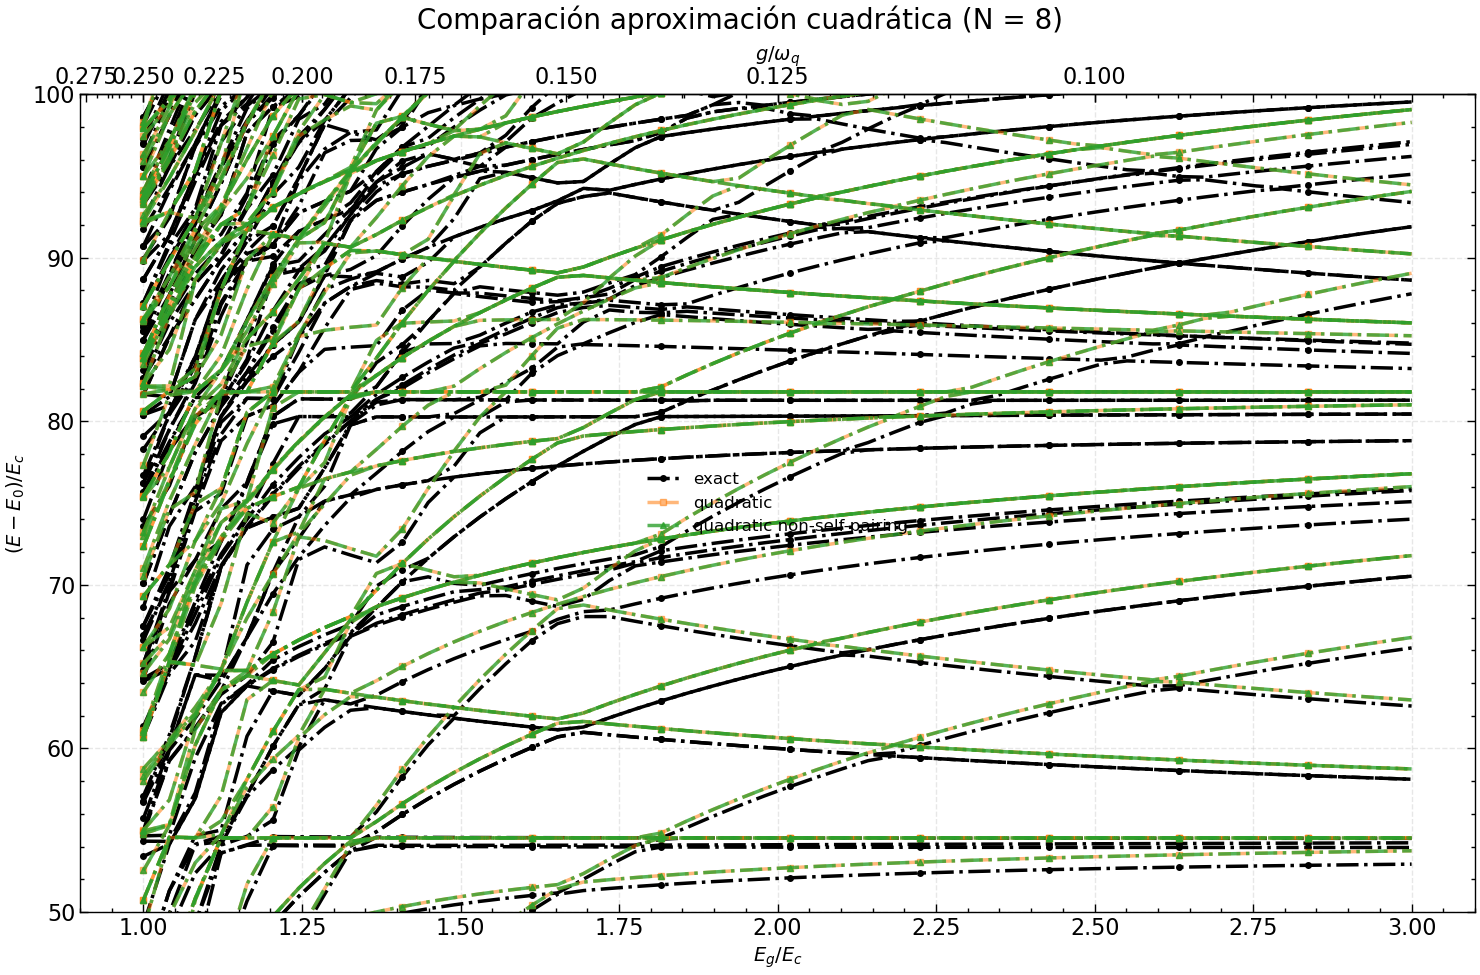

In [8]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Comparación aproximación cuadrática (N = 8)', fontsize=20)

# More distinct styles with different colors, line styles, and markers
styles = [
    {'color': "#000000", 'linestyle': '-.', 'linewidth': 2.5, 'marker': 'o', 'markersize': 4, 'markevery': 5},
    {'color': "#ff7e0e8d", 'linestyle': '--', 'linewidth': 2.5, 'marker': 's', 'markersize': 4, 'markevery': 5},
    {'color': "#2ca02cca", 'linestyle': '-.', 'linewidth': 2.5, 'marker': '^', 'markersize': 4, 'markevery': 5}
]
labels = ['exact', 'quadratic', 'quadratic non-self-pairing']

ax.set_xlabel('$E_g/E_c$', fontsize=14)
ax.set_ylabel('$(E- E_0)/E_c$', fontsize=14)

for energy_array, style, labl in zip(energy_matrix, styles, labels):
    ground = energy_array.T[0]
    for level_idx, level in enumerate(energy_array.T):
        if level_idx == 0:
            ax.plot(E_g_values, np.zeros_like(level), 
                   label=labl, **style)
        else:
            ax.plot(E_g_values, level - ground, **style)

y_min = 50.0
y_max = 100.0
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3, linestyle='--')

# Secondary x-axis: np.sqrt((E_j * E_c**3) / 2) / E_g
# Bottom axis is E_g/E_c, so E_g = x * E_c
def bottom_to_top(x):
    # x is E_g/E_c, so E_c/(4*E_g) = 1/(4*x)
    return 1 / (4 * x)

def top_to_bottom(x):
    # Inverse: E_g/E_c = 1/(4*x)
    return 1 / (4 * x)

ax2 = ax.secondary_xaxis('top', functions=(bottom_to_top, top_to_bottom))
ax2.set_xlabel(r'$g/\omega_q$', fontsize=14)

plt.legend(fontsize=12, framealpha=0.9)
fig.tight_layout()
fig.tight_layout()
plt.show()

/tmp/ipykernel_25374/328691673.py:37: RuntimeWarning: divide by zero encountered in divide
  return 1 / (4 * x)


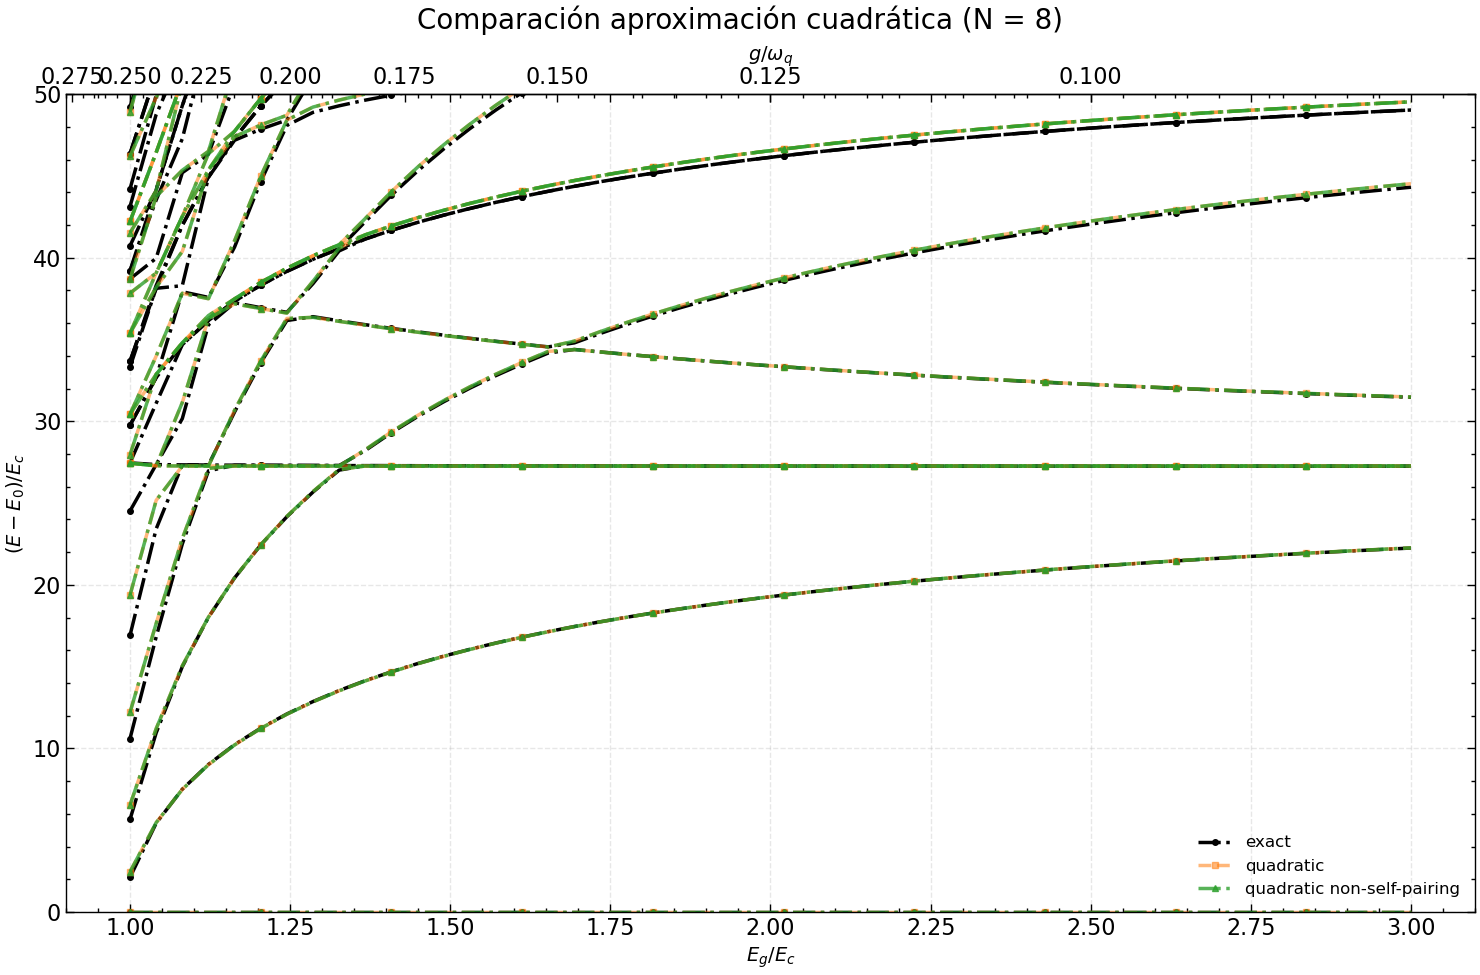

In [9]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Comparación aproximación cuadrática (N = 8)', fontsize=20)

# More distinct styles with different colors, line styles, and markers
styles = [
    {'color': "#000000", 'linestyle': '-.', 'linewidth': 2.5, 'marker': 'o', 'markersize': 4, 'markevery': 5},
    {'color': "#ff7e0e8d", 'linestyle': '--', 'linewidth': 2.5, 'marker': 's', 'markersize': 4, 'markevery': 5},
    {'color': "#2ca02cca", 'linestyle': '-.', 'linewidth': 2.5, 'marker': '^', 'markersize': 4, 'markevery': 5}
]
labels = ['exact', 'quadratic', 'quadratic non-self-pairing']

ax.set_xlabel('$E_g/E_c$', fontsize=14)
ax.set_ylabel('$(E- E_0)/E_c$', fontsize=14)

for energy_array, style, labl in zip(energy_matrix, styles, labels):
    ground = energy_array.T[0]
    for level_idx, level in enumerate(energy_array.T):
        if level_idx == 0:
            ax.plot(E_g_values, np.zeros_like(level), 
                   label=labl, **style)
        else:
            ax.plot(E_g_values, level - ground, **style)

y_min = 0.0
y_max = 50.0
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3, linestyle='--')

# Secondary x-axis: np.sqrt((E_j * E_c**3) / 2) / E_g
# Bottom axis is E_g/E_c, so E_g = x * E_c
def bottom_to_top(x):
    # x is E_g/E_c, so E_c/(4*E_g) = 1/(4*x)
    return 1 / (4 * x)

def top_to_bottom(x):
    # Inverse: E_g/E_c = 1/(4*x)
    return 1 / (4 * x)

ax2 = ax.secondary_xaxis('top', functions=(bottom_to_top, top_to_bottom))
ax2.set_xlabel(r'$g/\omega_q$', fontsize=14)

plt.legend(fontsize=12, framealpha=0.9)
fig.tight_layout()
fig.tight_layout()
plt.show()

La simulación muestra que hay muy poca diferencia entre mantener o no los términos de self pairing. Por otra parte la discrepancia con el espectro exacto sigue siendo apreciable para este régimen: la anarmonicidad no puede ser despreciada para los estados de mayor número de excitaciones. 